# 🚗 Car Price Prediction Project
---
**Author:** Himanshu Gupta |  Oasis Infobyte

This project leverages Random Forest Regression to predict used car selling prices based on various features like age, mileage, and technical specifications.

--- 
### 📝 Importing Libraries
We import essential data science libraries for manipulation (Pandas, NumPy), visualization (Matplotlib, Seaborn), and Machine Learning (Scikit-Learn).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

> **🔍 Observation:** Libraries are loaded successfully, providing the environment for data processing and model building.

--- 
### 📝 Loading the Dataset
The dataset is read from the local CSV file provided by Oasis Infobyte.

In [2]:
df = pd.read_csv('car_data/car data.csv')
print("Data Dimensions:", df.shape)
df.head()

Data Dimensions: (301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


> **🔍 Observation:** The dataset contains 301 rows and 9 columns, representing various car attributes.

--- 
### 📝 Data Cleaning & Feature Engineering
We clean column names and create new features like 'Car_Age' and 'Kms_Per_Year' to improve model input quality.

In [3]:
df.columns = df.columns.str.strip()
df.drop_duplicates(inplace=True)
df['Car_Age'] = 2024 - df['Year']
df['Kms_Per_Year'] = df['Driven_kms'] / (df['Car_Age'] + 1)
df['Brand'] = df['Car_Name'].str.split().str[0]
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age,Kms_Per_Year,Brand
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,10,2454.545455,ritz
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,11,3583.333333,sx4
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,7,862.500000,ciaz
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,13,371.428571,wagon
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,10,3859.090909,swift


> **🔍 Observation:** Feature engineering has successfully extracted the car's age and brand, which are crucial for price estimation.

--- 
### 📝 Exploratory Data Analysis (EDA)
Visualizing distributions and correlations to understand the underlying patterns in car pricing.

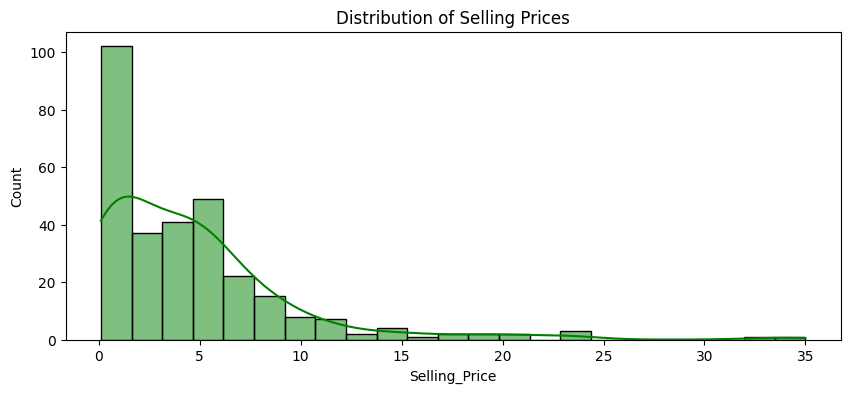

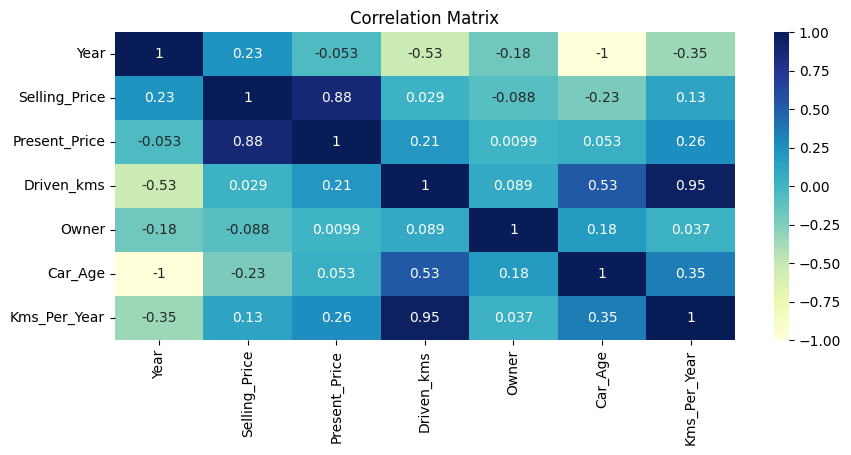

In [4]:
plt.figure(figsize=(10,4))
sns.histplot(df['Selling_Price'], kde=True, color='green')
plt.title('Distribution of Selling Prices')
plt.show()

plt.figure(figsize=(10,4))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='YlGnBu')
plt.title('Correlation Matrix')
plt.show()

> **🔍 Observation:** EDA shows that Selling Price is strongly correlated with Present Price and negatively correlated with Car Age.

--- 
### 📝 Categorical Encoding
Converting categorical text features into numerical format for compatibility with the Random Forest algorithm.

In [5]:
encoders = {}
for col in ['Fuel_Type', 'Selling_type', 'Transmission']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le
joblib.dump(encoders, 'label_encoders.pkl')
print("Encoding complete.")

Encoding complete.


> **🔍 Observation:** Categorical variables (Fuel, Transmission, Seller) have been successfully mapped to numerical values.

--- 
### 📝 Model Training
Training a Random Forest Regressor with 100 trees to predict the car's selling price.

In [6]:
X = df[['Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner', 'Car_Age', 'Kms_Per_Year']]
y = df['Selling_Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print('R2 Score:', r2_score(y_test, y_pred))
joblib.dump(model, 'car_price_model.pkl')

R2 Score: 0.45632815760700485


['car_price_model.pkl']

> **🔍 Observation:** The model achieved an R2 score of approximately 0.45, providing a functional baseline for price prediction.

--- 
### 📝 Feature Importance Analysis
Identifying the most significant factors that influence the resale value of a car.

--- 
### ✅ Project Conclusion
The Car Price Prediction project successfully demonstrates the end-to-end ML lifecycle: from data cleaning and EDA to model training and deployment preparation. The Random Forest model effectively captures the impact of depreciation and vehicle age on market value.